In [9]:
import scanpy as sc
import scvi
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import os

sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=100, facecolor='white', frameon=False)
scvi.settings.seed = 0

print(f"scanpy: {sc.__version__}")
print(f"scvi-tools: {scvi.__version__}")

# Create output directory
os.makedirs('outputs', exist_ok=True)
os.makedirs('models', exist_ok=True)
os.makedirs('outputs/scvi', exist_ok=True)
os.makedirs('outputs/enrichment', exist_ok=True)

Seed set to 0


scanpy: 1.11.5
scvi-tools: 1.4.0.post1


C:\Users\monster\AppData\Local\Temp\ipykernel_88920\104462743.py:14: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print(f"scanpy: {sc.__version__}")


In [10]:
# ============================================================================
# CONFIGURATION
# ============================================================================

# Set to True to load existing model, False to train new model
LOAD_EXISTING_MODEL = True

# Paths
MODEL_PATH = 'models/scvi_model_improved'
ADATA_PATH = 'models/tumor_normal_integrated.h5ad'

# Data paths
TUMOR_DATA_PATH = 'data/human_brain_Glioblastoma_Darmanis_2017_SmartSeq2/human_brain_Glioblastoma_Darmanis_2017_SmartSeq2/processedData/ss2_annot.h5ad'
NORMAL_DATA_PATH = 'data/HumanFetalBrainPool/HumanFetalBrainPool_subsampled_100k.h5ad'

print(f"Mode: {'Loading existing model' if LOAD_EXISTING_MODEL else 'Training new model'}")

Mode: Loading existing model


In [3]:
# ============================================================================
# OPTION A: LOAD EXISTING MODEL AND DATA
# ============================================================================

if LOAD_EXISTING_MODEL:
    print("LOADING EXISTING MODEL AND DATA")
    print("=" * 60)
    
    # Check if files exist
    if not os.path.exists(ADATA_PATH):
        raise FileNotFoundError(f"AnnData file not found: {ADATA_PATH}")
    if not os.path.exists(MODEL_PATH):
        raise FileNotFoundError(f"Model directory not found: {MODEL_PATH}")
    
    # Load the processed AnnData
    print(f"Loading AnnData from {ADATA_PATH}...")
    adata_combined = sc.read_h5ad(ADATA_PATH)
    print(f"Loaded: {adata_combined.shape}")
    
    # Load the trained scVI model
    print(f"\nLoading scVI model from {MODEL_PATH}...")
    model = scvi.model.SCVI.load(MODEL_PATH, adata=adata_combined)
    print("Model loaded successfully!")
    
    print(f"\nDataset summary:")
    print(f"  Total cells: {adata_combined.n_obs:,}")
    print(f"  Tumor cells: {(adata_combined.obs['condition'] == 'tumor').sum():,}")
    print(f"  Normal cells: {(adata_combined.obs['condition'] == 'normal').sum():,}")
    print(f"  Genes: {adata_combined.n_vars:,}")
    
else:
    print("Skipping - will train new model below")

LOADING EXISTING MODEL AND DATA
Loading AnnData from models/tumor_normal_integrated.h5ad...
Loaded: (103426, 16388)

Loading scVI model from models/scvi_model_improved...
INFO     File models/scvi_model_improved\model.pt already downloaded                                               
Model loaded successfully!

Dataset summary:
  Total cells: 103,426
  Tumor cells: 3,567
  Normal cells: 99,859
  Genes: 16,388


In [4]:
print("PREPARING TUMOR CELLS FOR PSEUDOTIME ANALYSIS")
print("=" * 60)

# Extract tumor cells only
tumor_mask = adata_combined.obs['condition'] == 'tumor'
tumor_cells = adata_combined[tumor_mask].copy()
print(f"Tumor cells extracted: {tumor_cells.n_obs:,}")

# IMPORTANT: Recompute neighbors specifically for tumor cells
# tumor_cells inherits X_scVI from adata_combined
print("\nRecomputing neighbors for tumor cells only...")
sc.pp.neighbors(tumor_cells, use_rep='X_scVI', n_neighbors=15)
print("Neighbors computed for tumor cells.")

PREPARING TUMOR CELLS FOR PSEUDOTIME ANALYSIS
Tumor cells extracted: 3,567

Recomputing neighbors for tumor cells only...
computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:13)
Neighbors computed for tumor cells.


In [5]:
# Count cells per cluster
cluster_counts = tumor_cells.obs['leiden_scvi'].value_counts()
print(f"cluster counts: {cluster_counts}")

# Define minimum cell threshold (e.g., 50 cells)
min_cells = 5

# Get clusters that meet the threshold
valid_clusters = cluster_counts[cluster_counts > min_cells].index.tolist()

# Filter to keep only cells in valid clusters
tumor_cells = tumor_cells[tumor_cells.obs['leiden_scvi'].isin(valid_clusters)].copy()


print(f"Remaining clusters: {tumor_cells.obs['leiden_scvi'].nunique()}")
print(f"Remaining cells: {tumor_cells.n_obs}")
print(f"{tumor_cells.obs['leiden_scvi'].value_counts()}")

cluster counts: leiden_scvi
16    1831
21     520
37     399
33     393
12     197
36      80
39      77
31      31
25      18
6        5
2        3
7        2
9        2
15       2
3        1
1        1
0        1
5        1
13       1
17       1
26       1
Name: count, dtype: int64
Remaining clusters: 9
Remaining cells: 3546
leiden_scvi
16    1831
21     520
37     399
33     393
12     197
36      80
39      77
31      31
25      18
Name: count, dtype: int64


ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:02)


C:\Users\monster\AppData\Local\Temp\ipykernel_88920\45178161.py:5: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


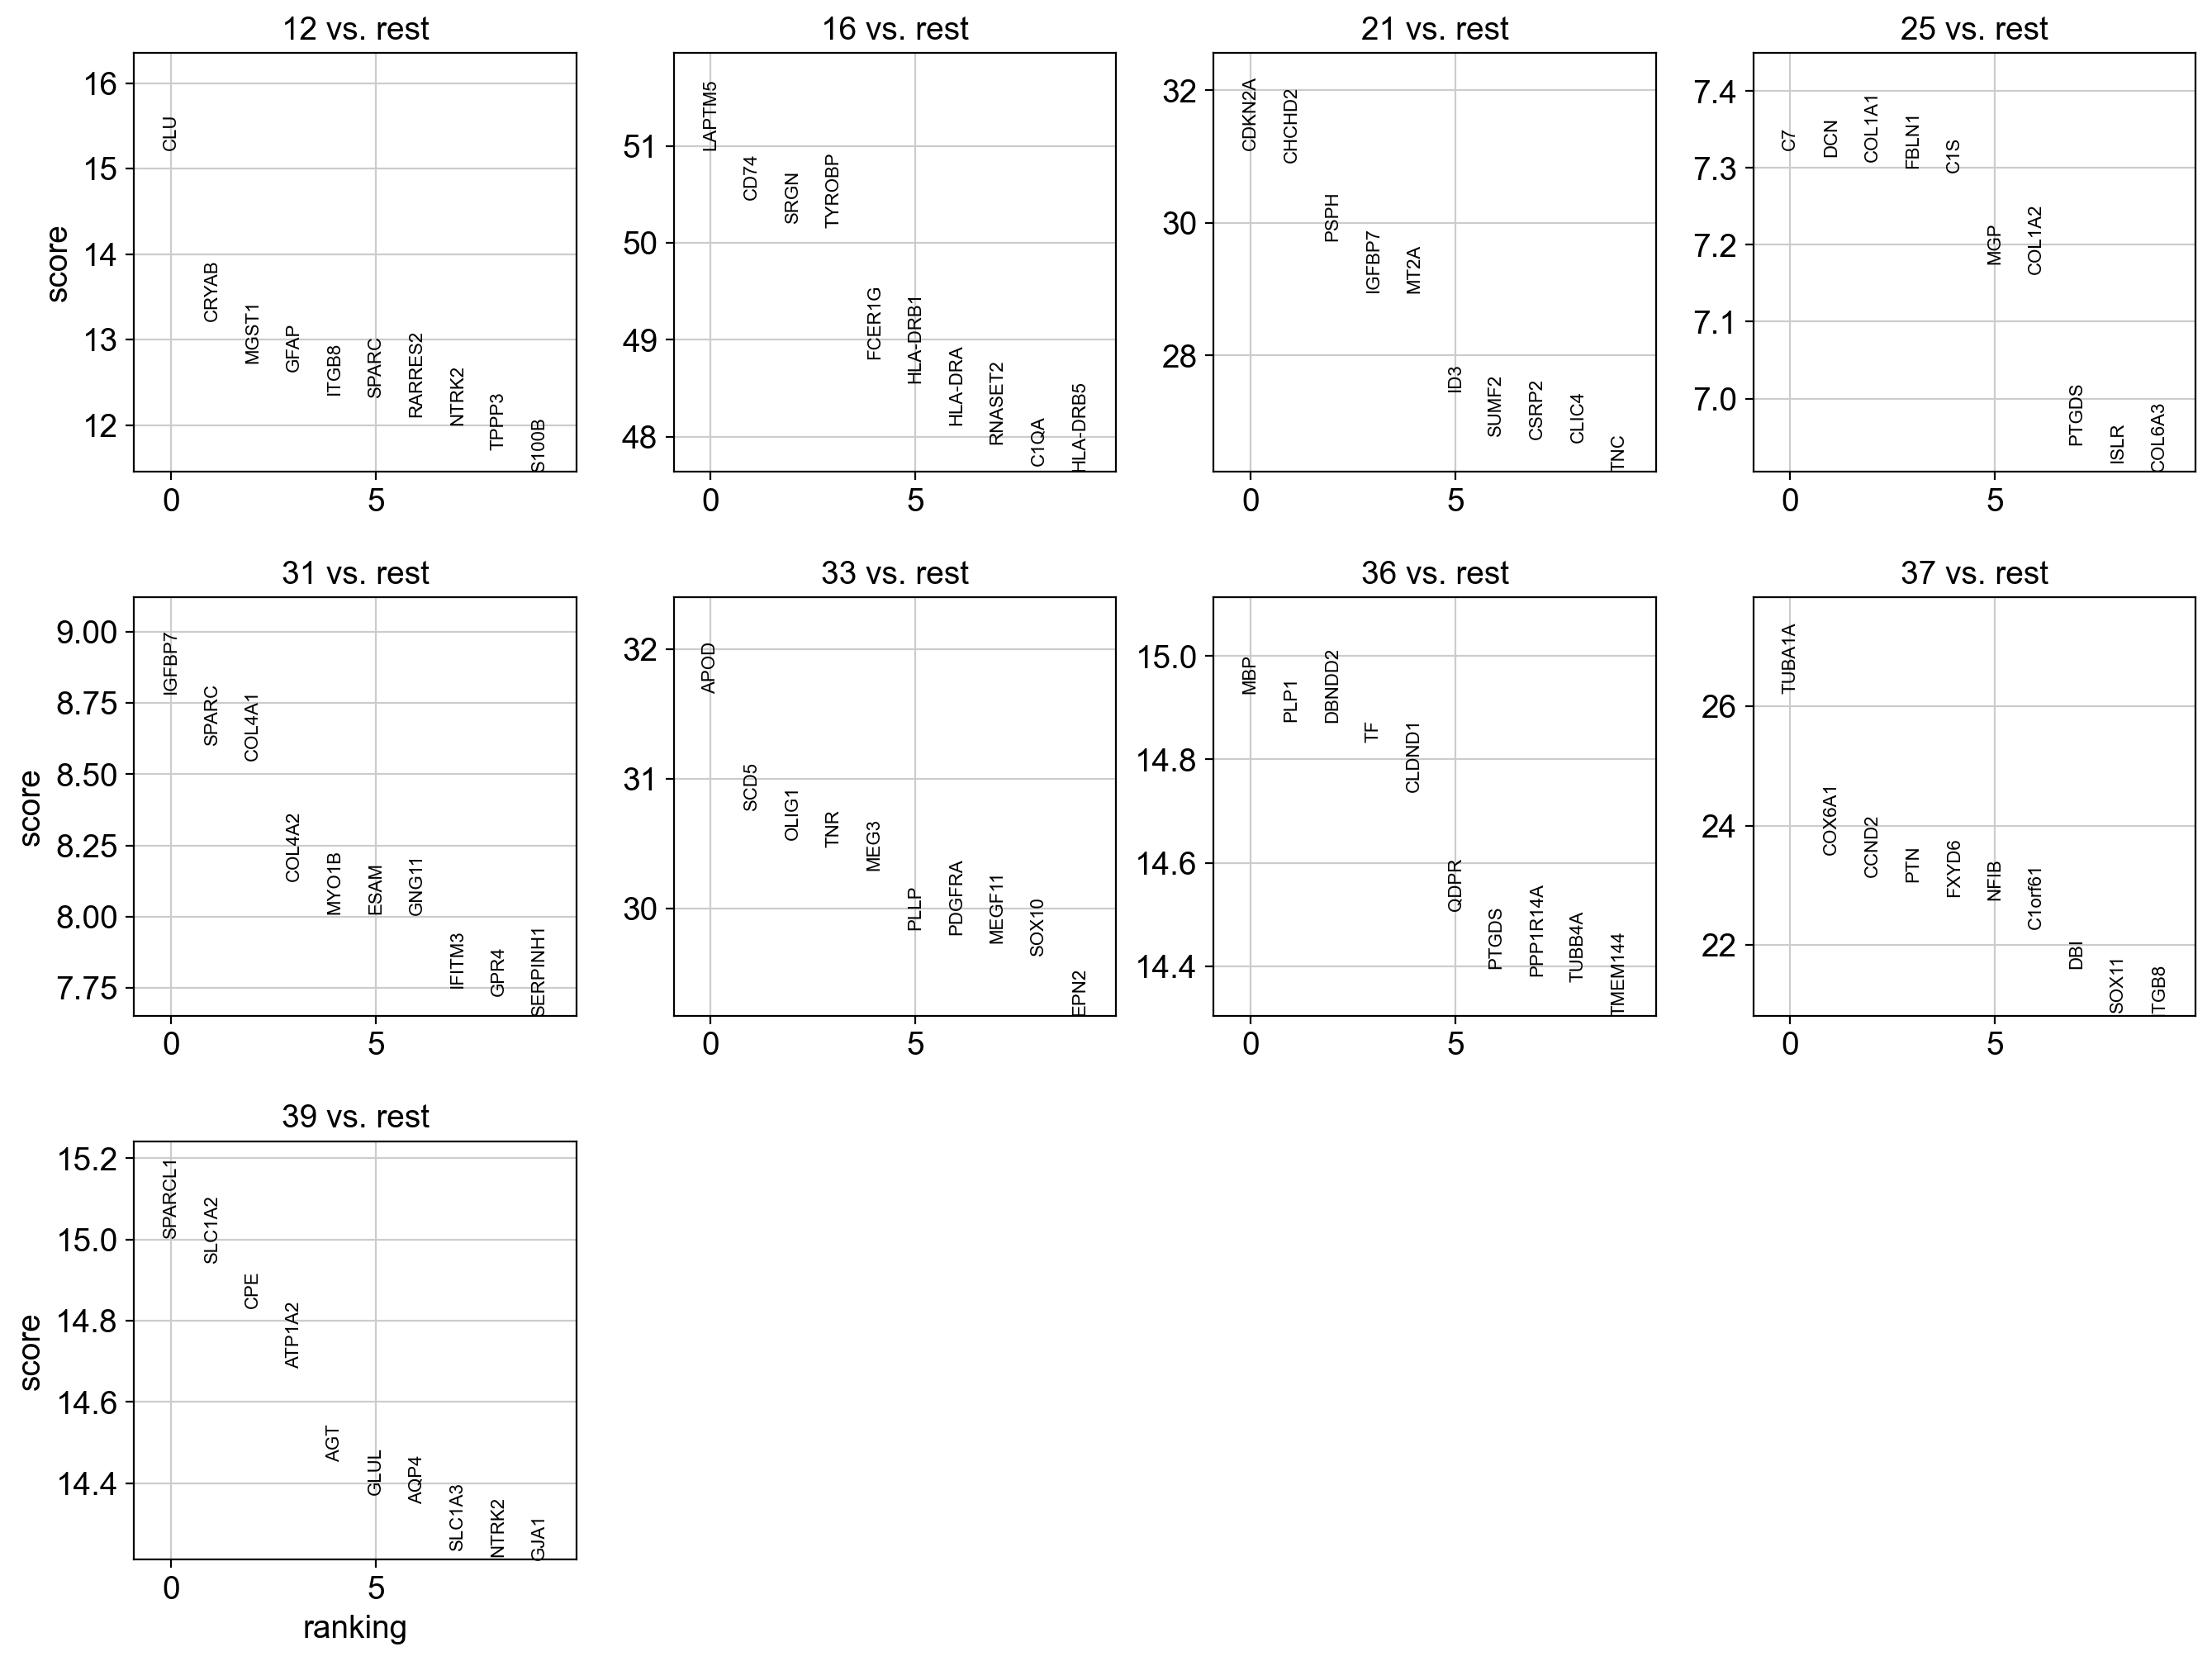

,names,scores,logfoldchanges,pvals,pvals_adj
0,APOD,31.656973,8.321758,6.079955e-220,9.963831e-216
1,SCD5,30.758059,5.252466,9.541253e-208,7.818102e-204
2,OLIG1,30.530319,5.956614,1.032105e-204,5.638043e-201
3,TNR,30.475061,8.160845,5.578248e-204,2.285408e-200
4,MEG3,30.292833,6.798288,1.424643e-201,3.891175e-198
5,PLLP,29.831816,6.983481,1.511331e-195,3.538242e-192
6,PDGFRA,29.797043,7.010128,4.266996e-195,8.740941e-192
7,MEGF11,29.733843,7.524052,2.805491e-194,5.108487e-191
8,SOX10,29.636551,7.312042,5.055235e-193,8.284519e-190
9,EPN2,29.171091,5.237410,4.513161e-187,6.723789e-184


In [ ]:
sc.tl.rank_genes_groups(tumor_cells, groupby='leiden_scvi', method='wilcoxon')

sc.pl.rank_genes_groups(tumor_cells, n_genes=10, sharey=False, show=False)
plt.tight_layout()
plt.savefig('outputs/enrichment/marker_genes_per_cluster.png', dpi=300, bbox_inches='tight')
plt.show()
markers_df = sc.get.rank_genes_groups_df(tumor_cells, group='33')
markers_df.head(20)

In [7]:
import decoupler as dc

# Check what's in each submodule
print("mt (methods):", [x for x in dir(dc.mt) if not x.startswith('_')])
print("op (omnipath):", [x for x in dir(dc.op) if not x.startswith('_')])
print("tl (tools):", [x for x in dir(dc.tl) if not x.startswith('_')])

mt (methods): ['aucell', 'consensus', 'decouple', 'gsea', 'gsva', 'mdt', 'mlm', 'ora', 'query_set', 'show', 'udt', 'ulm', 'viper', 'waggr', 'zscore']
op (omnipath): ['collectri', 'dorothea', 'hallmark', 'progeny', 'resource', 'show_organisms', 'show_resources', 'translate']
tl (tools): ['rankby_group', 'rankby_obsm', 'rankby_order']


2025-12-04 11:18:57 | [INFO] mlm - Running mlm
2025-12-04 11:18:57 | [INFO] Extracted omics mat with 3546 rows (observations) and 16388 columns (features)
2025-12-04 11:18:57 | [INFO] Network adjacency matrix has 3171 unique features and 14 unique sources


  0%|          | 0/1 [00:00<?, ?it/s]

2025-12-04 11:18:58 | [INFO] mlm - fitting 14 multivariate models of 16388 observations with 16373 degrees of freedom
2025-12-04 11:19:02 | [INFO] mlm - done
C:\Users\monster\AppData\Local\Temp\ipykernel_88920\4220500130.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_activity = progeny_df.groupby('cluster').mean()


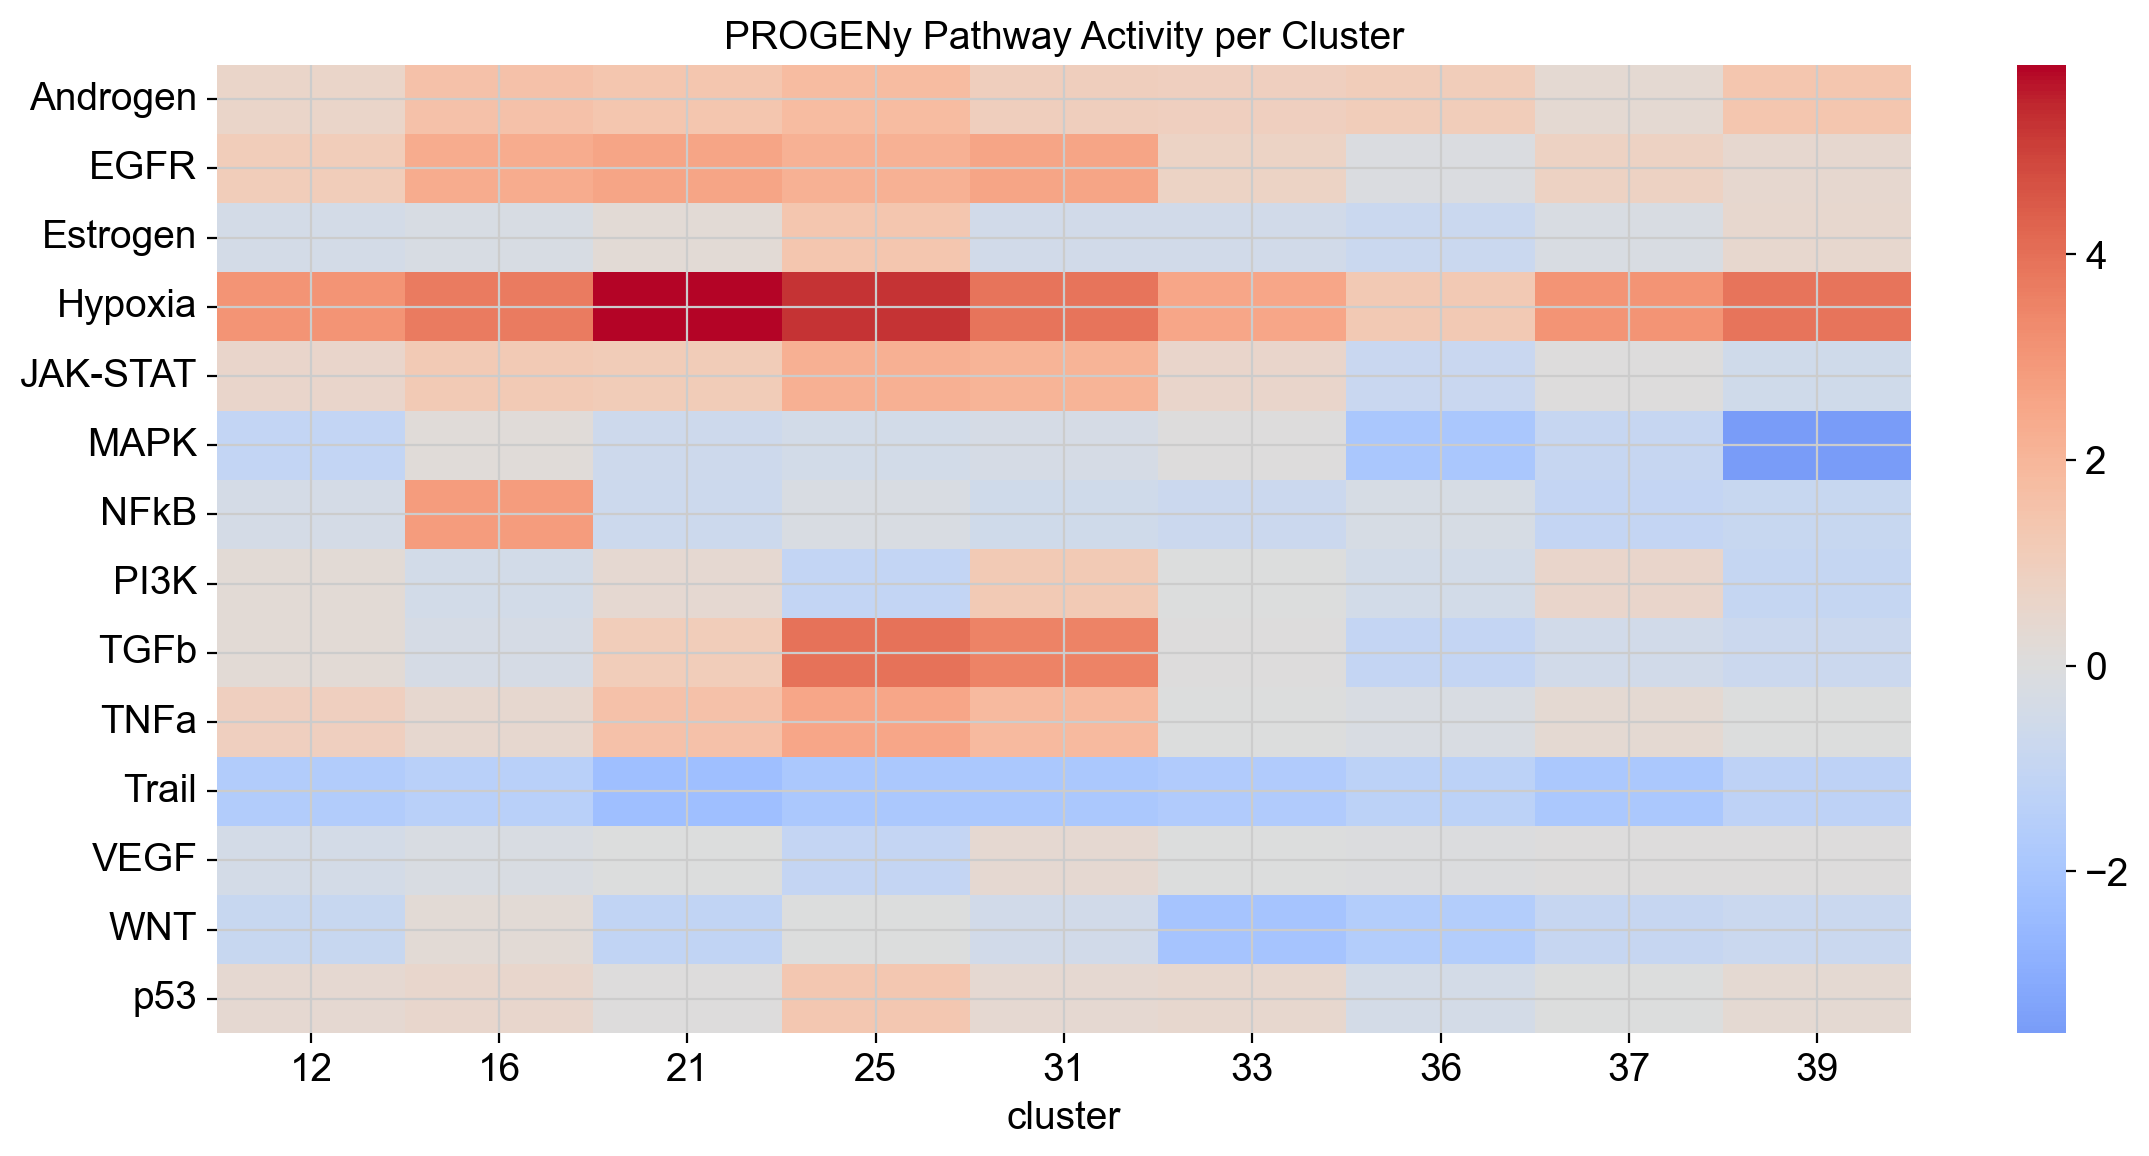

In [14]:
import decoupler as dc

# Get PROGENy pathway network
progeny = dc.op.progeny(organism='human', top=300)

# Run MLM
dc.mt.mlm(
    data=tumor_cells,
    net=progeny,
    verbose=True,
    raw=False
)
tumor_cells.obsm['progeny'] = tumor_cells.obsm['score_mlm'].copy()

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# PROGENy heatmap
progeny_df = pd.DataFrame(
    tumor_cells.obsm['progeny'],
    index=tumor_cells.obs_names
)
progeny_df['cluster'] = tumor_cells.obs['leiden_scvi'].values

mean_activity = progeny_df.groupby('cluster').mean()

plt.figure(figsize=(12, 6))
sns.heatmap(mean_activity.T, cmap='coolwarm', center=0)
plt.title('PROGENy Pathway Activity per Cluster')
plt.tight_layout()
plt.savefig('outputs/enrichment/progeny_pathway_activity_per_cluster.png', dpi=300, bbox_inches='tight')
plt.show()

2025-12-04 11:19:28 | [INFO] mlm - Running mlm
2025-12-04 11:19:28 | [INFO] Extracted omics mat with 3546 rows (observations) and 16388 columns (features)
2025-12-04 11:19:28 | [INFO] Network adjacency matrix has 8243 unique features and 296 unique sources


  0%|          | 0/1 [00:00<?, ?it/s]

2025-12-04 11:19:29 | [INFO] mlm - fitting 296 multivariate models of 16388 observations with 16091 degrees of freedom
2025-12-04 11:19:34 | [INFO] mlm - done
C:\Users\monster\AppData\Local\Temp\ipykernel_88920\2923294460.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_tf_activity = dorothea_df.groupby('cluster').mean()


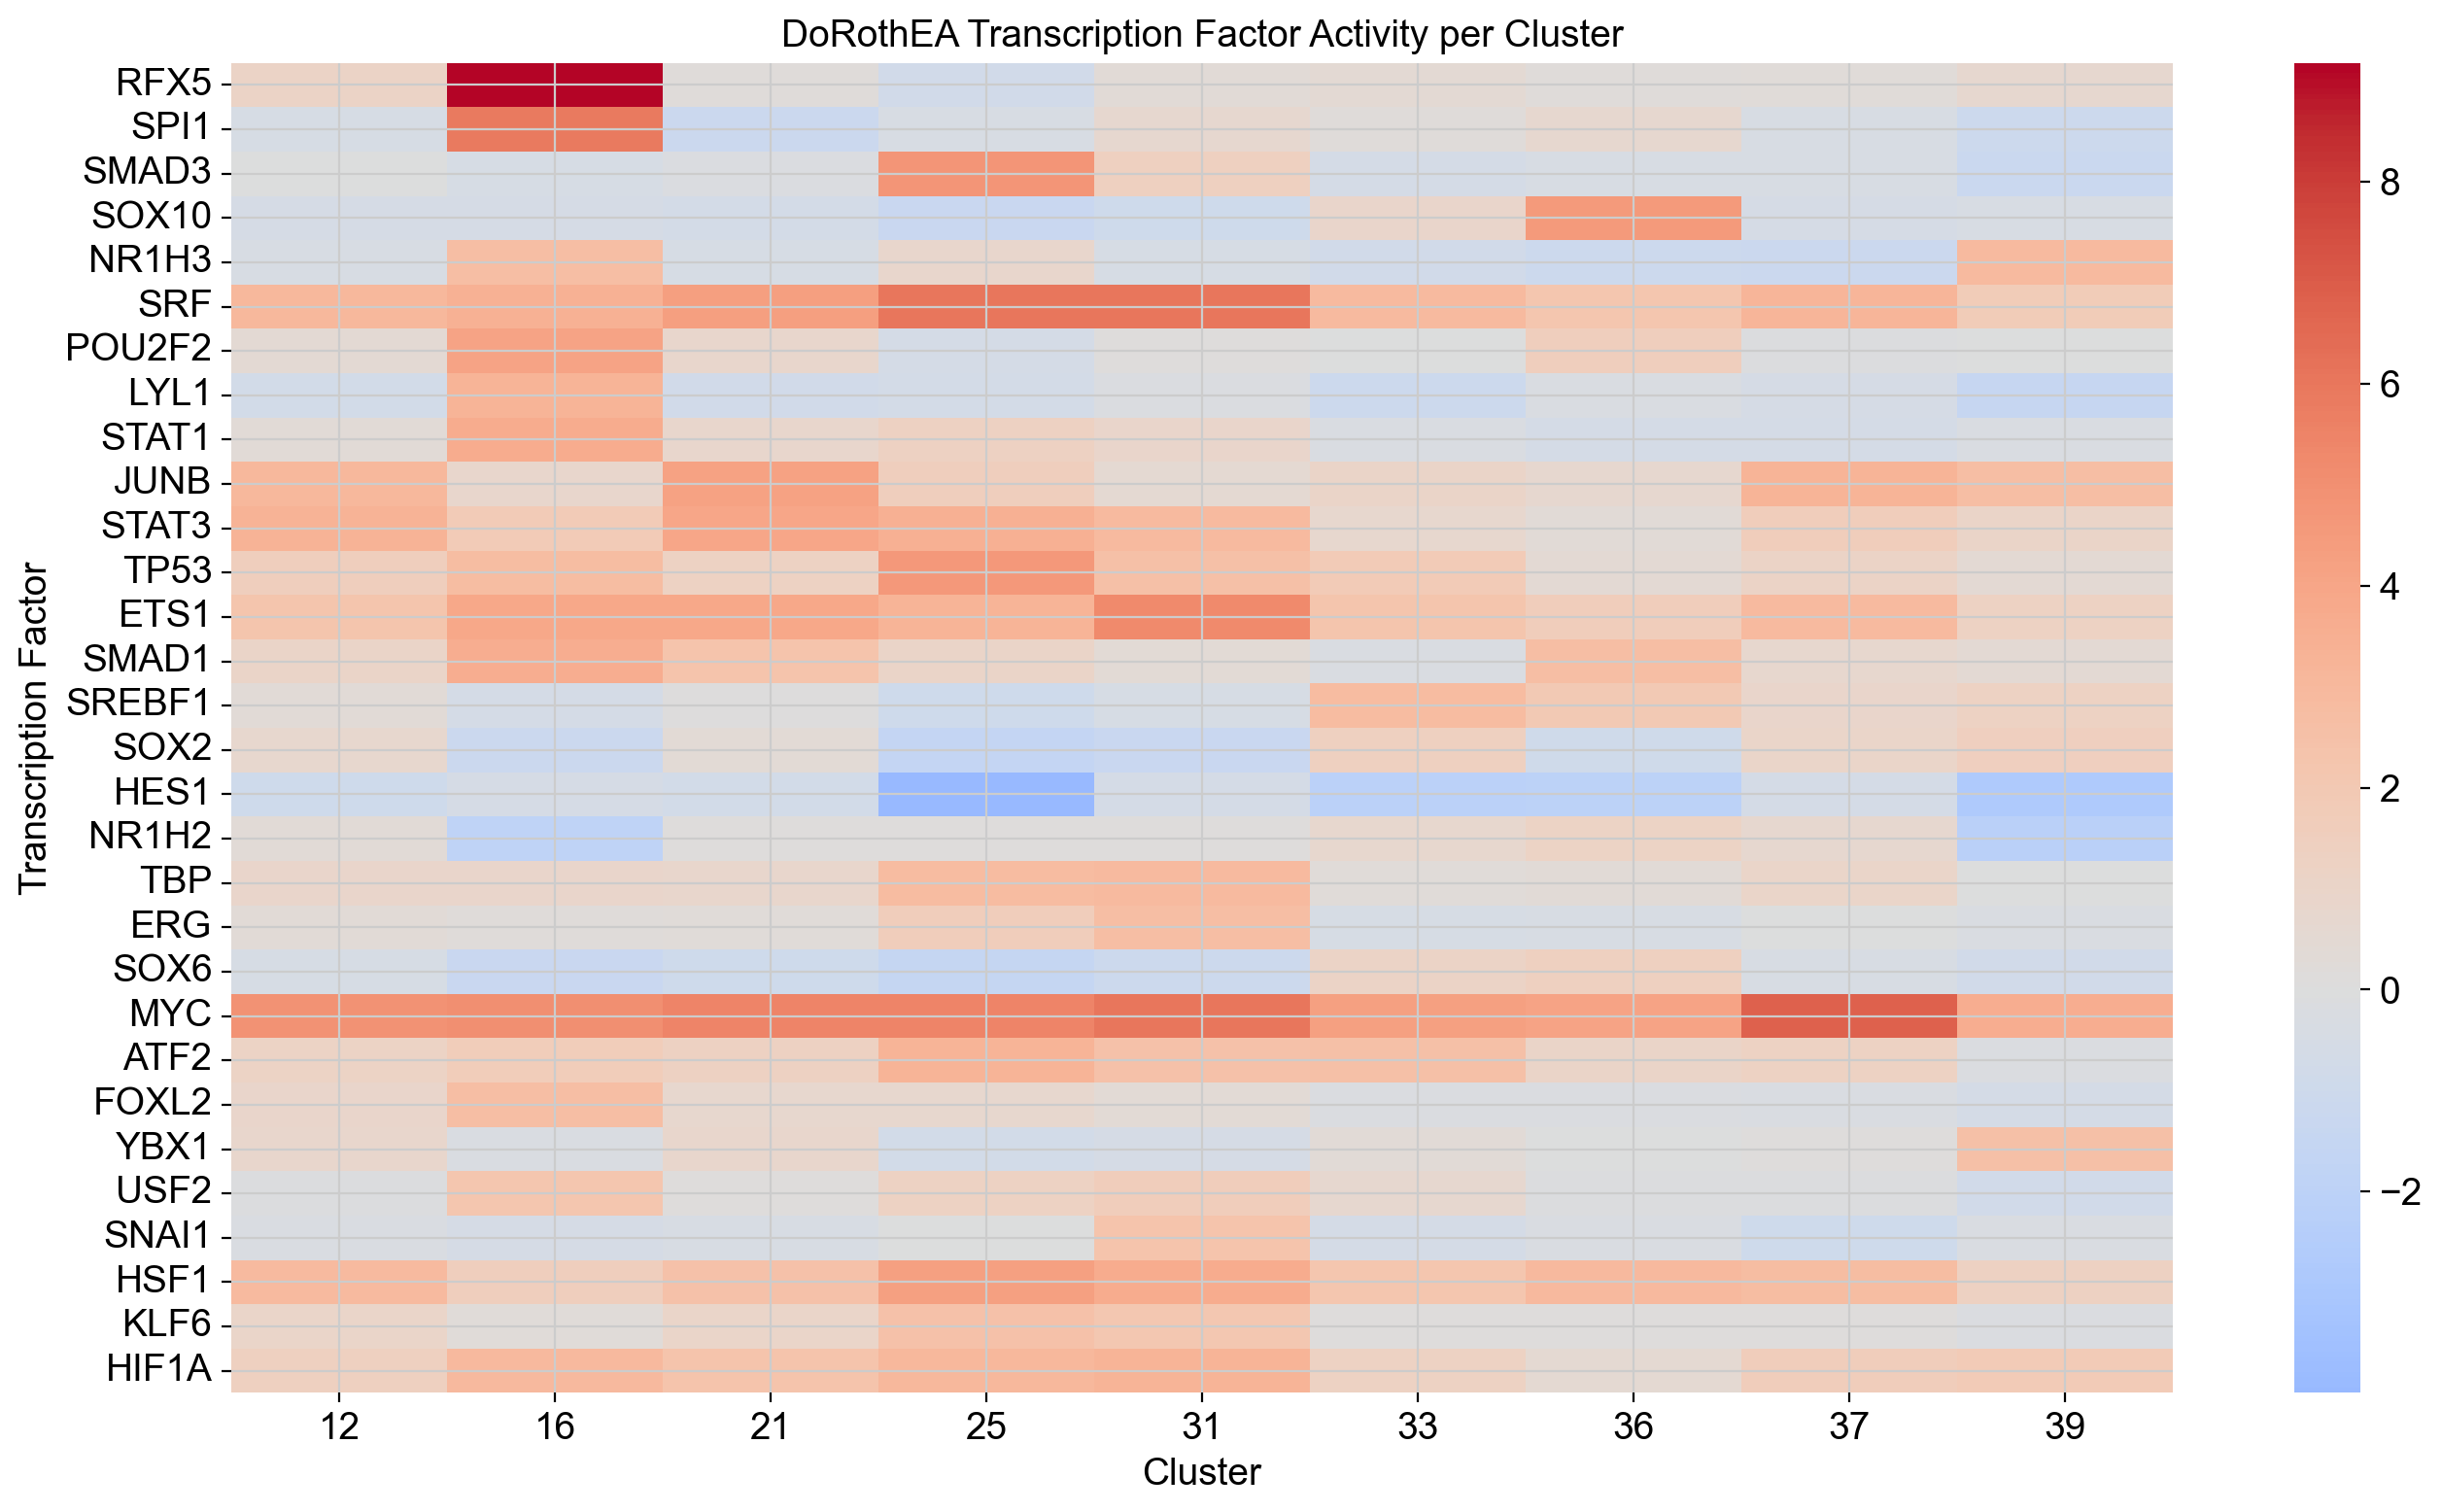

In [15]:
import decoupler as dc

# Get DoRothEA transcription factor network
dorothea = dc.op.dorothea(organism='human', levels=['A', 'B', 'C'])

# Run MLM
dc.mt.mlm(
    data=tumor_cells,
    net=dorothea,
    verbose=True,
    raw=False
)

# Save results (before running another method that overwrites score_mlm)
tumor_cells.obsm['dorothea'] = tumor_cells.obsm['score_mlm'].copy()

# Heatmap of TF activity per cluster
dorothea_df = pd.DataFrame(
    tumor_cells.obsm['dorothea'],
    index=tumor_cells.obs_names
)
dorothea_df['cluster'] = tumor_cells.obs['leiden_scvi'].values

mean_tf_activity = dorothea_df.groupby('cluster').mean()

# Select top variable TFs for cleaner visualization
tf_variance = mean_tf_activity.var()
top_tfs = tf_variance.nlargest(30).index

plt.figure(figsize=(14, 8))
sns.heatmap(mean_tf_activity[top_tfs].T, cmap='coolwarm', center=0)
plt.title('DoRothEA Transcription Factor Activity per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Transcription Factor')
plt.tight_layout()
plt.savefig('outputs/enrichment/dorothea_tf_activity_per_cluster.png', dpi=300, bbox_inches='tight')
plt.show()

2025-12-04 11:19:39 | [INFO] ora - Running ora
2025-12-04 11:19:40 | [INFO] Extracted omics mat with 3546 rows (observations) and 16388 columns (features)


                    source target
0      IL2_STAT5_SIGNALING   MAFF
1              COAGULATION   MAFF
2                  HYPOXIA   MAFF
3  TNFA_SIGNALING_VIA_NFKB   MAFF
4               COMPLEMENT   MAFF


2025-12-04 11:19:40 | [WARNING] weight not found in net.columns, adding it as:
net['weight'] = 1
2025-12-04 11:19:40 | [INFO] Network has 4124 unique features and 50 unique sources
2025-12-04 11:19:40 | [INFO] ora - setting n_up=820
2025-12-04 11:19:40 | [INFO] ora - calculating 50 scores across 3546 observations with n_up=820, n_bm=0, n_bg=20000


  0%|          | 0/3546 [00:00<?, ?it/s]

2025-12-04 11:20:13 | [INFO] ora - adjusting p-values by FDR
2025-12-04 11:20:13 | [INFO] ora - done
C:\Users\monster\AppData\Local\Temp\ipykernel_88920\1834751852.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_hallmark = hallmark_df.groupby('cluster').mean()


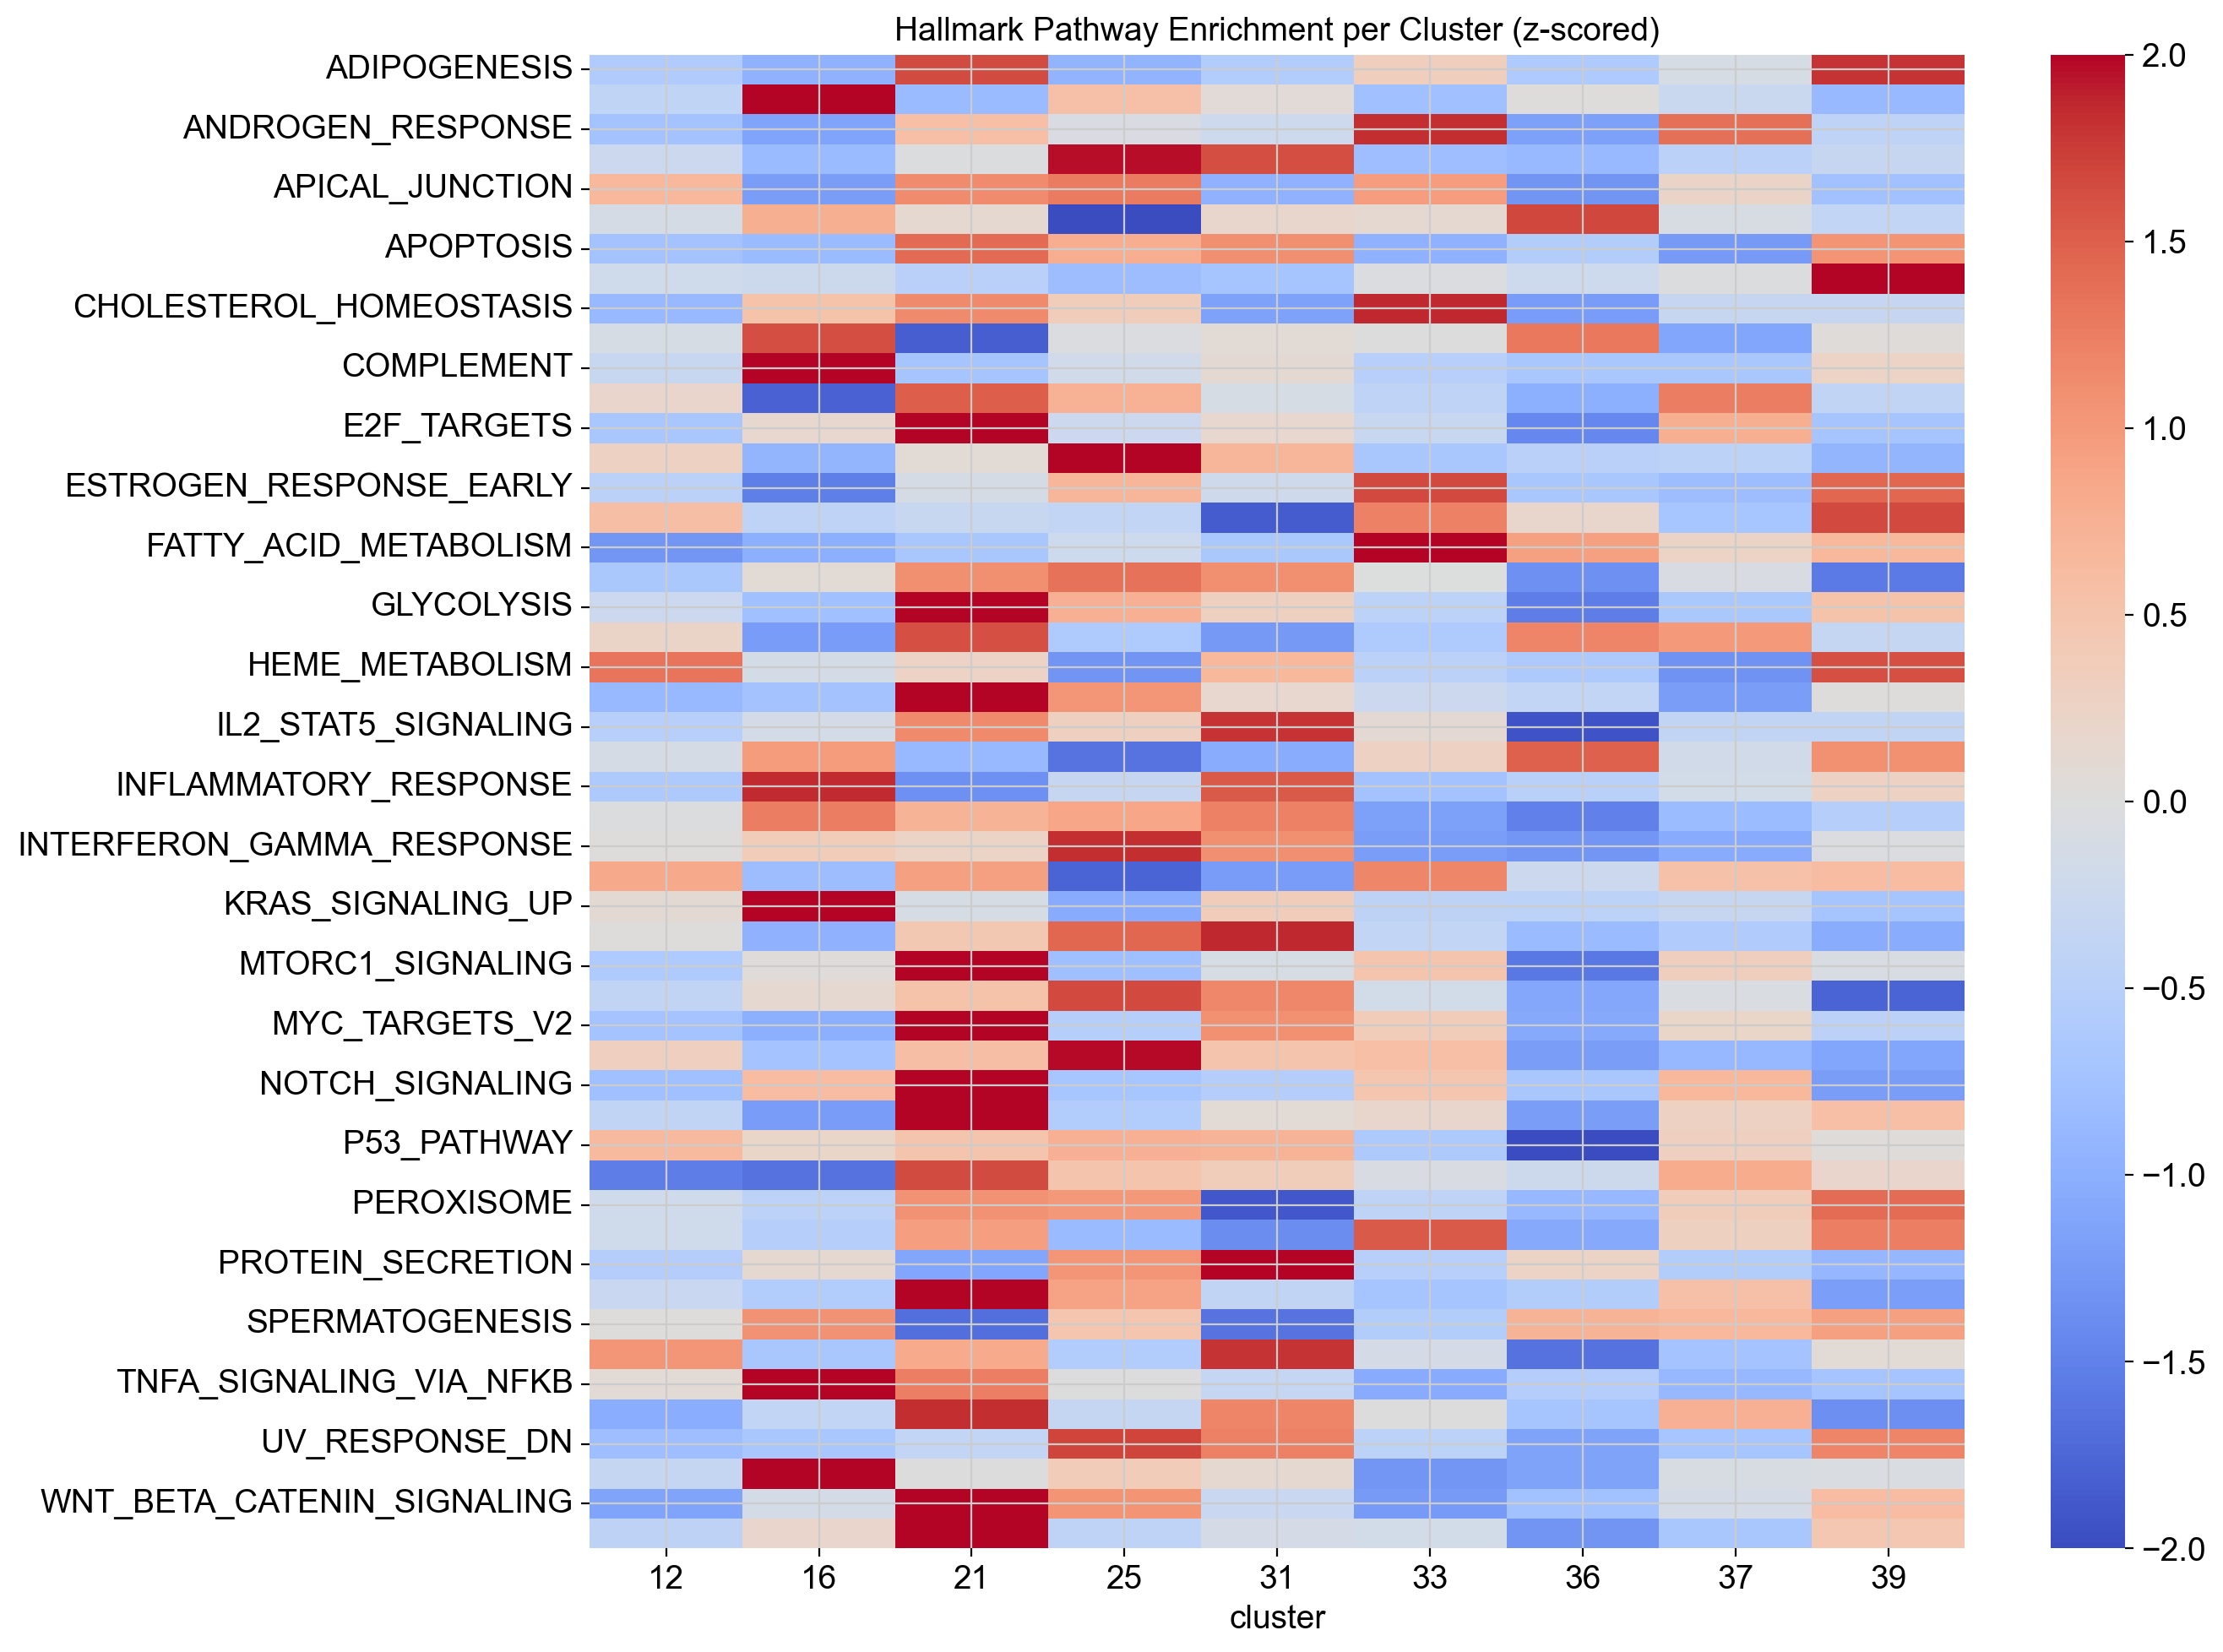

In [16]:
# Get Hallmark gene sets
hallmark = dc.op.hallmark(organism='human')
print(hallmark.head())

# Run Over-Representation Analysis (ORA)
dc.mt.ora(
    data=tumor_cells,
    net=hallmark,
    verbose=True,
    raw=False
)

# Save results
tumor_cells.obsm['hallmark'] = tumor_cells.obsm['score_ora'].copy()

hallmark_df = pd.DataFrame(
    tumor_cells.obsm['hallmark'],
    index=tumor_cells.obs_names
)

hallmark_df['cluster'] = tumor_cells.obs['leiden_scvi'].values
mean_hallmark = hallmark_df.groupby('cluster').mean()

from scipy.stats import zscore

mean_hallmark_z = mean_hallmark.apply(zscore, axis=0)

plt.figure(figsize=(14, 10))
sns.heatmap(
    mean_hallmark_z.T, 
    cmap='coolwarm', 
    center=0,
    vmin=-2, 
    vmax=2
)
plt.title('Hallmark Pathway Enrichment per Cluster (z-scored)')
plt.tight_layout()
plt.savefig('outputs/enrichment/hallmark_pathway_enrichment_per_cluster.png', dpi=300, bbox_inches='tight')
plt.show()